# Feature Transformatn
- it is used to transform the distributn to normal form or make the normal distributn

> Several types of transformatn :
1. log trans
2. reciprocal trans
3. power(sq/sqrt)
4. Box-Cox
5. Yeo-Johnson

> 3 types of transformers :
1. Functn Transformer  --> log, reciprocal, sq/sqrt, custom
2. Power Trans  --> Box-cox, yeo-johnson
3. Quantile transformer

> How to find if data is normal?
- find sns.distplot
- find pd.skew(if 0, then normal)
- QQ plot(most reliable)

> Log Transform
- Applying log 
- It should not be applied on Negative val
- It should be applied on RIGHT Skewed distributn

> Reciprocal Transform(1/x)
- It makes big val small and small val big

> Square Transformer(x^2)
- It is applied on Left Skewed distributn

> Sqrt Transform
- Doing sqrt of distributn

# Example

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\titanic\train.csv', usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [10]:
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y, test_size=0.2, random_state=42)

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\3298070597.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_tr['Age'])


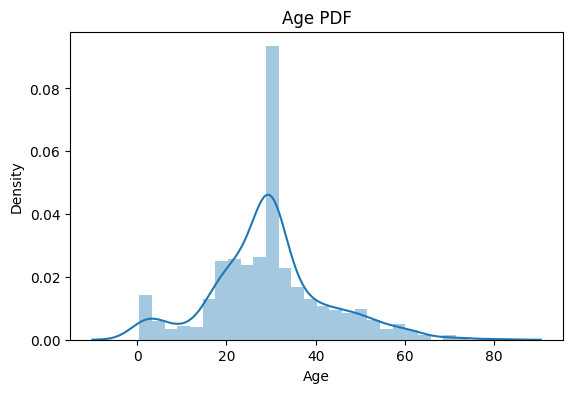

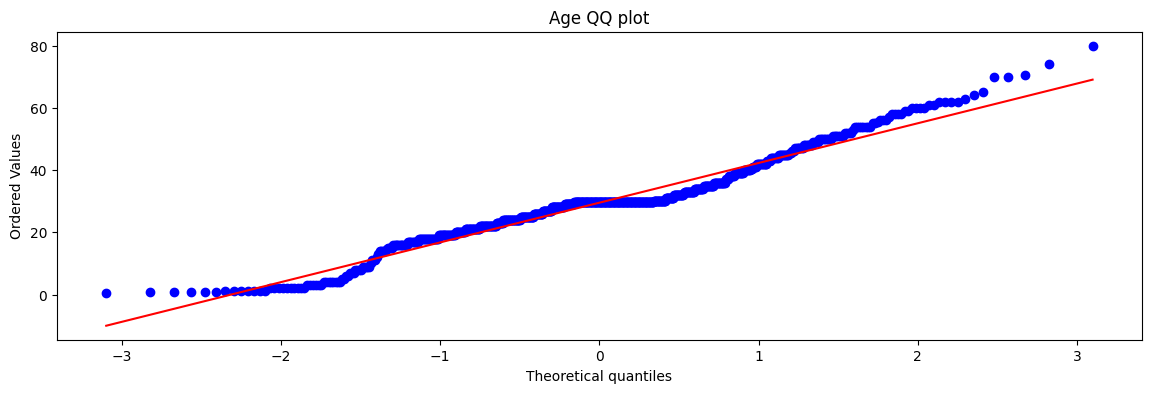

In [16]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_tr['Age'])
plt.title('Age PDF')

plt.figure(figsize=(14,4))
stats.probplot(x_tr['Age'], dist='norm', plot=plt)
plt.title('Age QQ plot')

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\915517565.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_tr['Fare'])


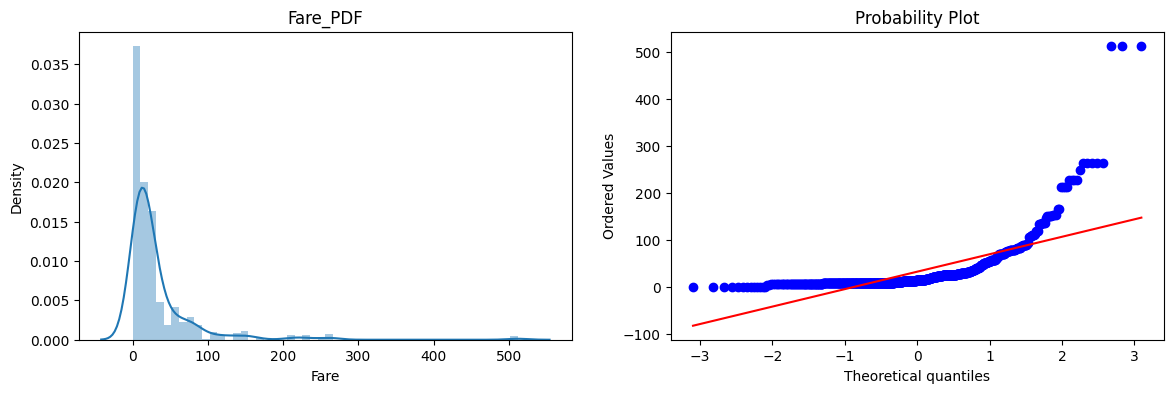

In [18]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_tr['Fare'])
plt.title('Fare_PDF')

plt.subplot(122)
stats.probplot(x_tr['Fare'], dist='norm', plot=plt)
plt.show()

In [19]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [20]:
clf1.fit(x_tr, y_tr)
clf2.fit(x_tr, y_tr)

y_pred1 = clf1.predict(x_ts)
y_pred2 = clf2.predict(x_ts)

print('Acc of LR', accuracy_score(y_ts, y_pred1))
print('Acc of DT', accuracy_score(y_ts, y_pred2))

Acc of LR 0.6480446927374302
Acc of DT 0.6815642458100558


# Function Transformer

> Using Functn Transformer
- Diff b/w np.log & np.log1p is that np.log1p add 1 to value and then do log which eliminates log0 condn

> Syntax to apply Fn transformer:
1. load the fn trans
2. now fit_trans train & test data
3. load model
4. fit transformed data into model and predct using it
5. Now check accuracy score
6. For cross checking use cross_val_score

In [21]:
trf = FunctionTransformer(func=np.log1p)

In [22]:
x_tr_transformed = trf.fit_transform(x_tr)
x_ts_transformed = trf.transform(x_ts)

In [27]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(x_tr_transformed, y_tr)
clf2.fit(x_tr_transformed, y_tr)

y_pred = clf1.predict(x_ts_transformed)
y_pred3 = clf2.predict(x_ts_transformed)

print('Acc of LR', accuracy_score(y_ts, y_pred))
print('Acc of DT', accuracy_score(y_ts, y_pred3))

Acc of LR 0.6815642458100558
Acc of DT 0.6871508379888268


- Now cross checking or cross validating accuracy score using cross val score
- Cross val score means calculating 10 times train-test and finding mean 

In [28]:
x_transformed = trf.fit_transform(x)

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf1, x_transformed, y, scoring='accuracy', cv=10)))
print('DT', np.mean(cross_val_score(clf2, x_transformed, y, scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.6554931335830212


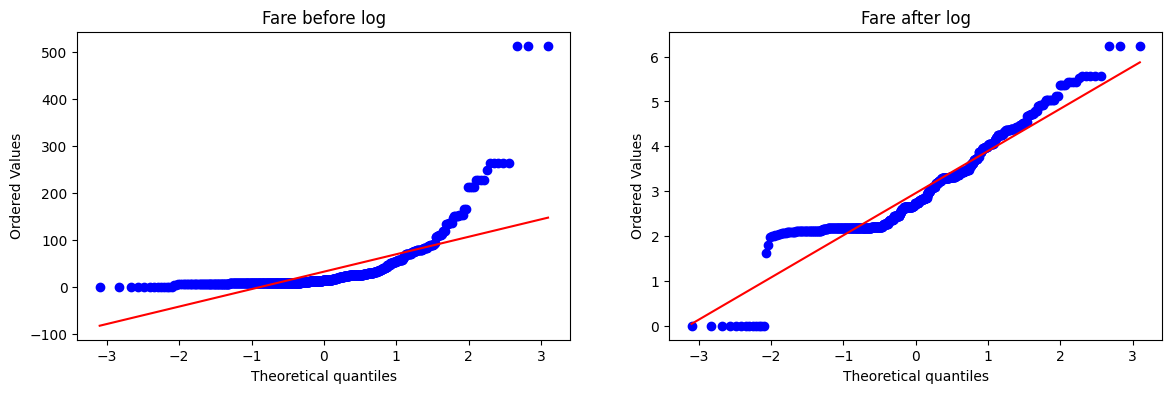

In [31]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_tr['Fare'], dist='norm', plot=plt)
plt.title('Fare before log')

plt.subplot(122)
stats.probplot(x_tr_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare after log')

plt.show()

- This graph shows Fare col is being transformed and it give distributn equivalent to normal distributn

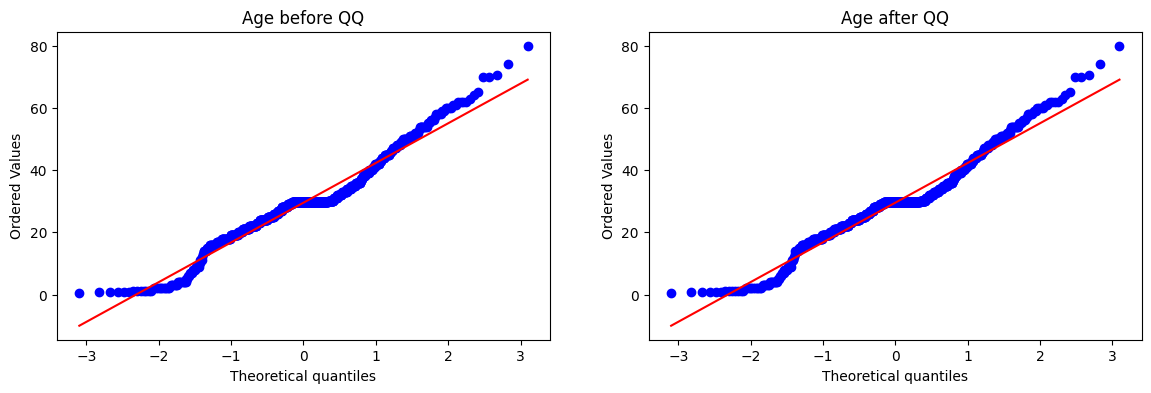

In [32]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_tr['Age'], dist='norm', plot=plt)
plt.title('Age before QQ')

plt.subplot(122)
stats.probplot(x_tr['Age'], dist='norm', plot=plt)
plt.title('Age after QQ')

plt.show()

- Here this data distribun become wrong as it is not right skewed

In [33]:
# now we try to perform log transform only on Fare col
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

x_tr_transformed2 = trf.fit_transform(x_tr)
x_ts_transformed2 = trf.transform(x_ts)

- we can cross check this by doing cross_val score but this col doesnot show any change

> Decision tree does not get affected by data distributn, So it does not depend on data distributn for better accuracy.

> Linear or Logistic regression are those algo's which get affected by data dustributn

<h4>Making custom transformer</h4>

In [35]:
def apply_transform(tranform):
    x = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log', FunctionTransformer(tranform),['Fare'])], remainder='passthrough')

    x_trans = trf.fit_transform(x)

    clf = LogisticRegression()

    print('Accuracy', np.mean(cross_val_score(clf, x_trans,y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(x['Fare'], dist='norm', plot=plt)
    plt.title('Fare before transform')

    plt.subplot(122)
    stats.probplot(x['Fare'], dist='norm', plot=plt)
    plt.title('Fare after transform')

    plt.show()

Accuracy 0.6431335830212235


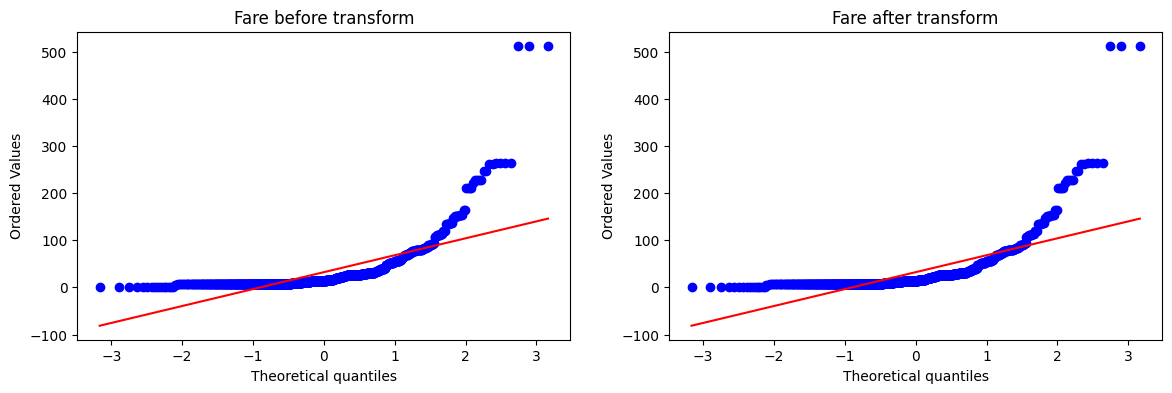

In [36]:
apply_transform(lambda x: x**2)

# Power Transformer

<h3>Box-Cox Transform</h3>

> Formula:
- Xi^l = (Xi^l - 1)/l, if(l != 0)  OR (log(Xi)), if(l = 0)
- Here Xi(input), l(lambda for every input col)
- The exponent here is a var called lambda(l) that varies the range of -5 to 5 and all ni the process of searching, we examine all val of l, Finally we choose the optimal val for var resulting in the best approximatn to a normal distributn
- It is strictly aplicable only on numbers greater than 0(not </=0)

<h3>Yeo-Johnson Transform</h3>

- This transformatn is somewhat of an adjustment to the Box-Cox transformatn by which we can apply it to negative no's

- Example:

In [48]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer

In [38]:
df1 = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\concrete_data.csv')

In [39]:
df1.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [43]:
df1.shape

(1030, 9)

In [41]:
df1.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [42]:
df1.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [53]:
X = df1.iloc[:,1:8]
Y = df1.iloc[:,-1]

In [54]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

- Doing without power trasnformer

In [58]:
l2 = LinearRegression()

l2.fit(x_train, y_train)
y_pred = l2.predict(x_test)

r2_score(y_test, y_pred)

0.5582175790319941

In [60]:
# cross checking with cross val score
lr = LinearRegression()
np.mean(cross_val_score(lr, X, Y, scoring='r2'))

np.float64(0.3111361238369776)

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1911285473.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


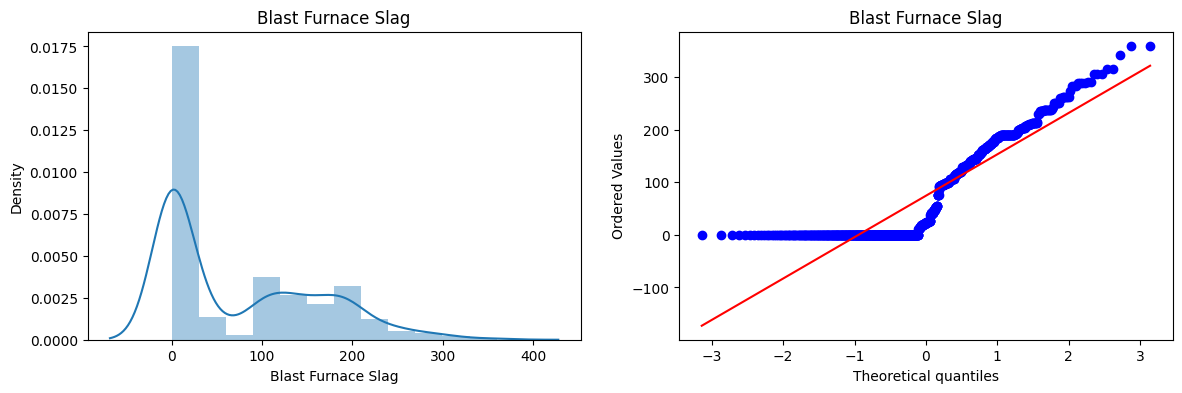

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1911285473.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


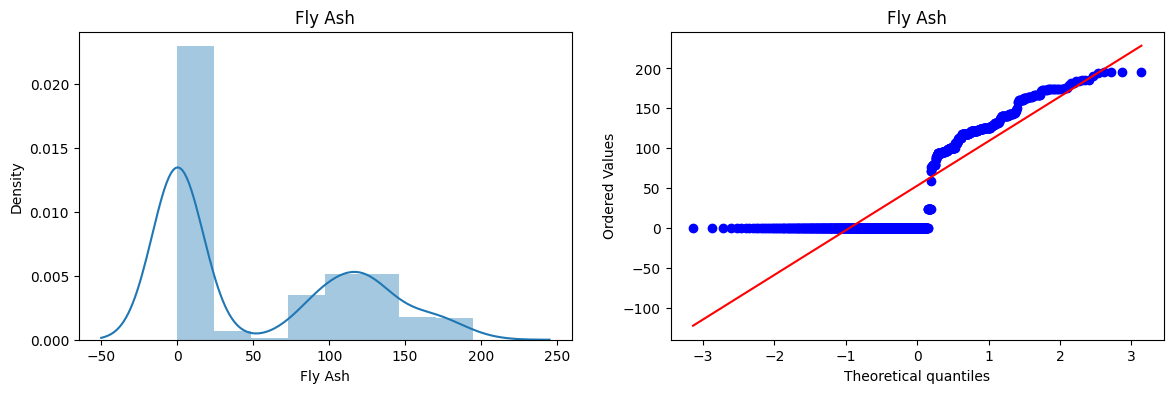

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1911285473.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


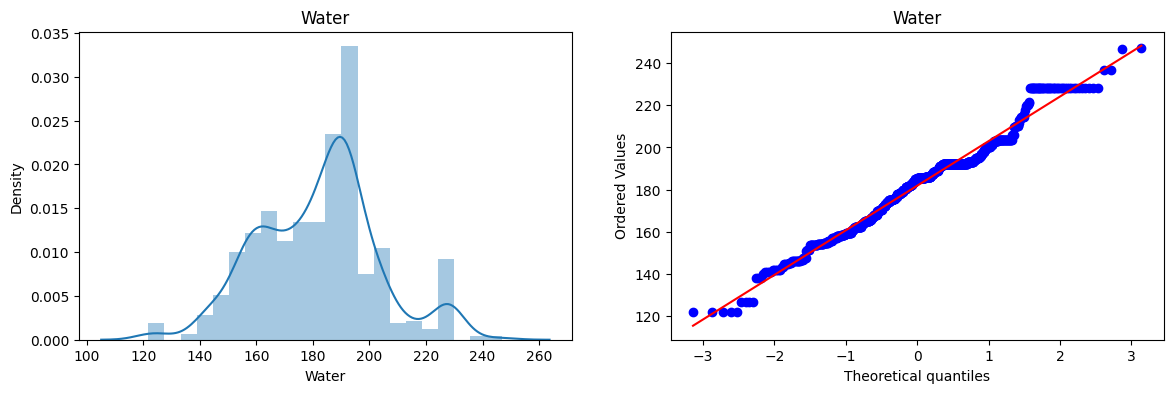

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1911285473.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


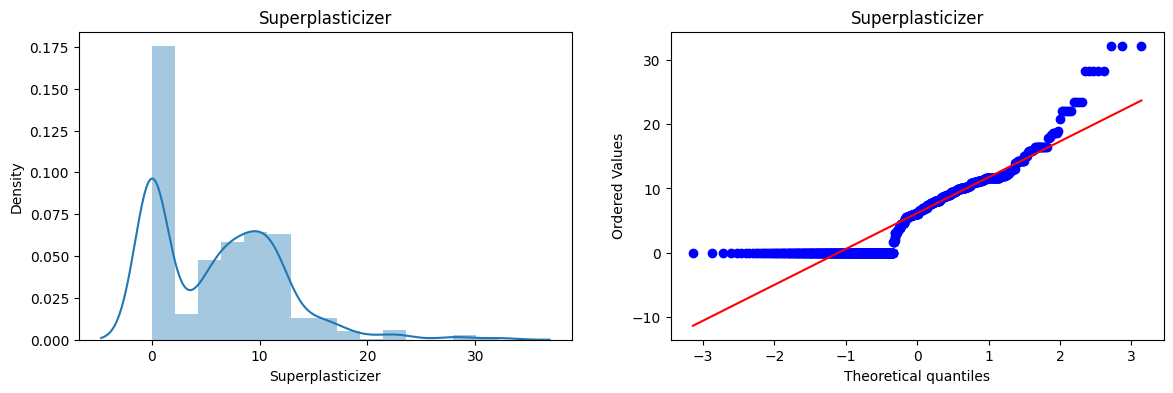

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1911285473.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


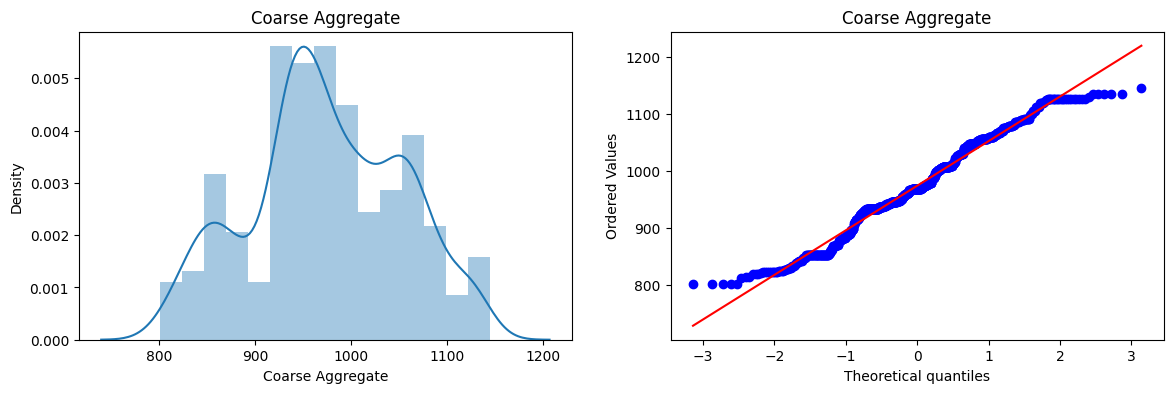

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1911285473.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


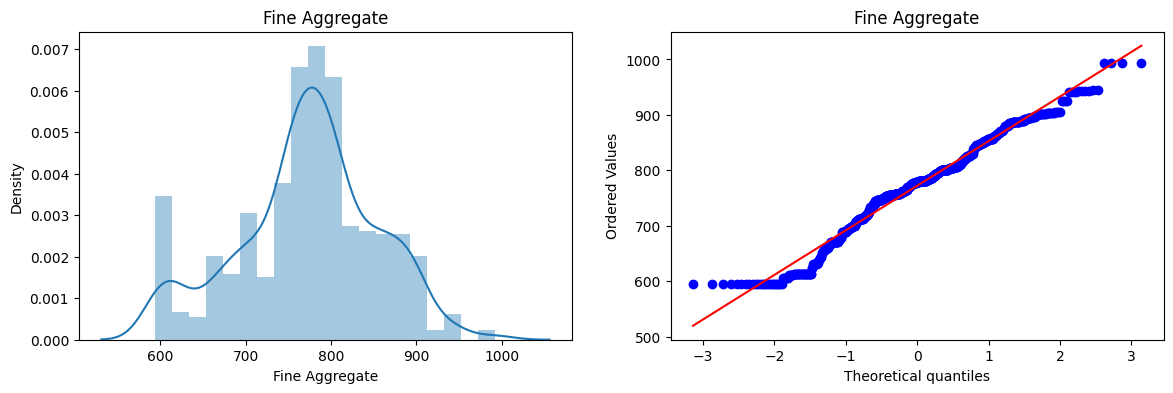

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1911285473.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])


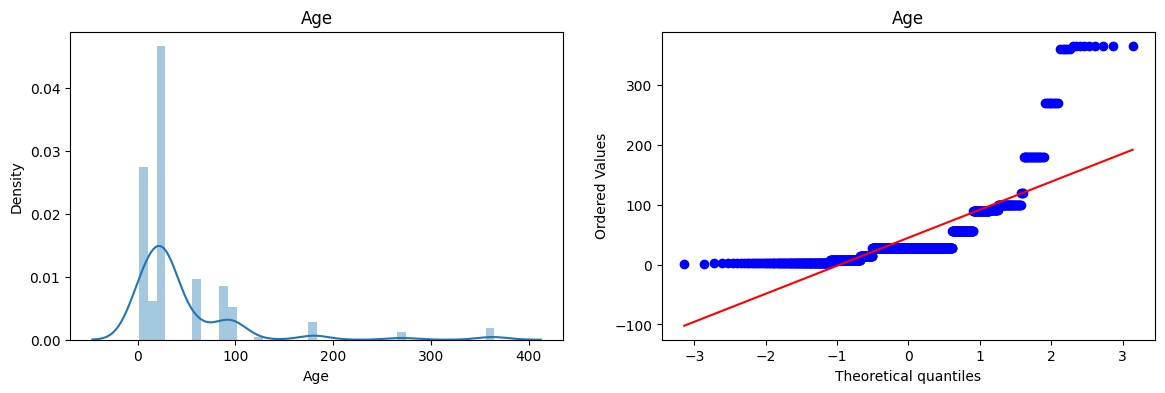

In [61]:
for col in x_train.columns :
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col], dist='norm', plot=plt)
    plt.title(col)

    plt.show()

- There is no need of doing standardiztn or scaling as Powertransformer fn have default para which is true for scaling
- If you have 0 in data cols but you want to apply box-cox, then add some minor val(ex:0.0000001) which make it greater than one

> Applying Box-Cox transform

In [62]:
# pt.lmbda will give all col lambdas
pt = PowerTransformer(method='box-cox')

x_train_trans = pt.fit_transform(x_train+0.000001)
x_test_trans = pt.transform(x_test+0.000001)

pd.DataFrame({'cols':x_train.columns, 'box_cox_lambda':pt.lambdas_})

,cols,box_cox_lambda
0,Blast Furnace Slag,0.025093
1,Fly Ash,-0.038970
2,Water,0.772682
3,Superplasticizer,0.098811
4,Coarse Aggregate,1.129813
5,Fine Aggregate,1.782018
6,Age,0.066631


In [64]:
# Applying Linear regression on transformed data
lr = LinearRegression()
lr.fit(x_train_trans, y_train)

y_p = lr.predict(x_test_trans)
r2_score(y_test, y_p)

0.6954513839639116

In [71]:
pt = PowerTransformer(method='box-cox')
trans1 = pt.fit_transform(X+0.000001)

lr = LinearRegression()
np.mean(cross_val_score(lr, trans1, Y, scoring='r2'))

np.float64(0.40727389787299995)

C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1692261991.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])
C:\Users\HP\AppData\Local\Temp\ipykernel_2884\1692261991.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_trans['Age'])


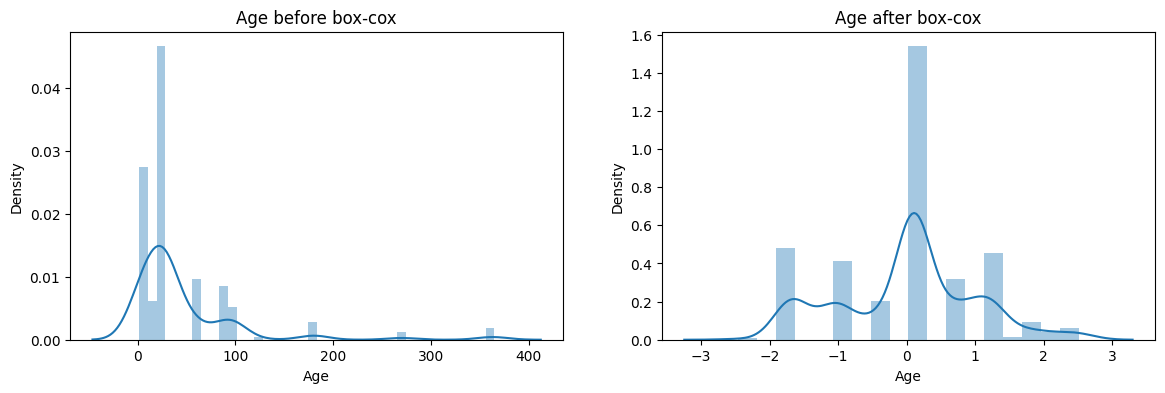

In [67]:
# Before and after box_cox
x_train_trans = pd.DataFrame(x_train_trans, columns=x_train.columns)

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age before box-cox')

plt.subplot(122)
sns.distplot(x_train_trans['Age'])
plt.title('Age after box-cox')
plt.show()

- Applying Yeo-johnson

In [72]:
pt = PowerTransformer()

transX = pt.fit_transform(x_train)
transXs = pt.transform(x_test)

lr = LinearRegression()
lr.fit(transX, y_train)

pred = lr.predict(transXs)

r2_score(y_test, pred)

0.7050503179193552

In [74]:
# to convet numpy arr to df
pd.DataFrame({'cols':x_train.columns, 'yeo_lambda':pt.lambdas_})

,cols,yeo_lambda
0,Blast Furnace Slag,0.016633
1,Fly Ash,-0.136480
2,Water,0.808438
3,Superplasticizer,0.264160
4,Coarse Aggregate,1.129395
5,Fine Aggregate,1.830764
6,Age,0.001771


In [73]:
# applying cross
pt = PowerTransformer()
transX2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr, transX2, Y, scoring='r2'))

np.float64(0.39528258772191327)

> Summary 
- if you want to apply transformatn on linear/logistic
- Chec for normal distributn
- if not normal, apply power trans class(perform better than fn transformer)
- Now load the transformer in var
- fit_transform train & test data
- then load model and fit training data and result
- now predict on transformed data
- And check it's r2_score
- You can cross validate using cross val score